# End-to-End Machine Learning Exercise


**Prepared by:** **Ali H. El-Kassas**  
*Senior Data Scientist | Machine Learning Instructor*

This notebook is intended to help students practice the complete machine learning workflow, including exploratory data analysis, data preprocessing, feature engineering, model training, hyperparameter tuning, and error analysis.

Complete all `TODO` sections.

### Objectives

Build a machine learning pipeline that predicts the Manufacturer Suggested Retail Price (MSRP) of a car.

- Frame the problem
- Select a Performance Measure
- Quick look on the data
- Train/Validation/Test split
- EDA
- Preprocessing
- Pipelines
- Modeling
- Fine-Tuning
- Error Analysis
- Final Evaluation
- Deploy the model

In [141]:
# TODO: Load the dataset
import pandas as pd

df = pd.read_csv('data.csv')
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


## Initial Inspection
Inspect shape, dtypes, missing values, duplicates and descriptive statistics.

In [193]:
# TODO
df.head(20)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650,50.000000,0.149180
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350,50.000000,0.149180
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450,38.333333,0.114371
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500,38.333333,0.114371
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,31200,38.333333,0.114314
6,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,26,17,3916,44100,50.000000,0.149105
7,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,39300,50.000000,0.149105
8,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,36900,38.333333,0.114314
9,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,27,18,3916,37200,38.333333,0.114257


In [143]:
df.MSRP.value_counts(ascending=False)

MSRP
2000     1036
29995      19
25995      19
20995      16
27995      16
         ... 
18855       1
22575       1
20050       1
26965       1
50920       1
Name: count, Length: 6049, dtype: int64

In [144]:
# TODO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [145]:
df.shape

(11914, 16)

In [146]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [147]:
df=df.dropna(subset=["Engine Fuel Type","Engine HP","Engine Cylinders","Number of Doors"])

In [148]:
df=df.drop("Market Category", axis=1)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11812 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11812 non-null  object 
 1   Model              11812 non-null  object 
 2   Year               11812 non-null  int64  
 3   Engine Fuel Type   11812 non-null  object 
 4   Engine HP          11812 non-null  float64
 5   Engine Cylinders   11812 non-null  float64
 6   Transmission Type  11812 non-null  object 
 7   Driven_Wheels      11812 non-null  object 
 8   Number of Doors    11812 non-null  float64
 9   Vehicle Size       11812 non-null  object 
 10  Vehicle Style      11812 non-null  object 
 11  highway MPG        11812 non-null  int64  
 12  city mpg           11812 non-null  int64  
 13  Popularity         11812 non-null  int64  
 14  MSRP               11812 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 1.4+ MB


In [150]:
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
10015,Dodge,Stratus,2005,regular unleaded,200.0,6.0,AUTOMATIC,front wheel drive,4.0,Midsize,Sedan,25,19,1851,23335
257,Mercedes-Benz,350-Class,1990,diesel,134.0,6.0,AUTOMATIC,rear wheel drive,4.0,Large,Sedan,23,19,617,2098
6855,Lincoln,MKC,2017,regular unleaded,240.0,4.0,AUTOMATIC,front wheel drive,4.0,Compact,4dr SUV,28,21,61,35720
8334,Ford,Ranger,2009,regular unleaded,143.0,4.0,MANUAL,rear wheel drive,2.0,Compact,Regular Cab Pickup,26,21,5657,16395
11058,Toyota,Tundra,2017,regular unleaded,381.0,8.0,AUTOMATIC,four wheel drive,4.0,Large,Extended Cab Pickup,17,13,2031,36480


In [151]:
df.duplicated().sum()

np.int64(720)

In [152]:
df.drop_duplicates(inplace=True)

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11092 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11092 non-null  object 
 1   Model              11092 non-null  object 
 2   Year               11092 non-null  int64  
 3   Engine Fuel Type   11092 non-null  object 
 4   Engine HP          11092 non-null  float64
 5   Engine Cylinders   11092 non-null  float64
 6   Transmission Type  11092 non-null  object 
 7   Driven_Wheels      11092 non-null  object 
 8   Number of Doors    11092 non-null  float64
 9   Vehicle Size       11092 non-null  object 
 10  Vehicle Style      11092 non-null  object 
 11  highway MPG        11092 non-null  int64  
 12  city mpg           11092 non-null  int64  
 13  Popularity         11092 non-null  int64  
 14  MSRP               11092 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 1.4+ MB


In [157]:
# This is for the feature engineerign I add it here to make it a simpler process
df['Engine HP per Cylinder'] = df['Engine HP'] / df['Engine Cylinders'].replace(0, np.nan)
df['Engine HP per Year'] = df['Engine HP'] / df['Year']
df.head(1)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584


In [158]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
count,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,1.109200e+04,11079.000000,11092.000000
mean,2010.693833,253.528579,5.687973,3.450415,26.272899,19.300667,1556.681302,4.190853e+04,44.145569,0.126025
std,7.241249,110.184621,1.766331,0.874700,7.481404,6.605683,1443.586149,6.174305e+04,11.560334,0.054628
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03,15.500000,0.027500
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.153750e+04,35.000000,0.085700
50%,2015.000000,240.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.059750e+04,44.375000,0.118989
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.302250e+04,50.500000,0.150794
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06,100.000000,0.498506


## Train / Validation / Test Split
Split data into Train, Validation and Test sets.

In [159]:
# TODO
from sklearn.model_selection import train_test_split


X = df.drop(columns = 'MSRP') # features, input
y = df['MSRP'] # label, output


X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=.2, random_state=500) # testing


X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=500) # training, val


## Exploratory Data Analysis

### Numerical Features



- Histograms
- KDE plots
- Boxplots
- Distribution of MSRP
- Identify skewed features

ValueError: supplied range of [15.5, inf] is not finite

<Figure size 40000x10000 with 0 Axes>

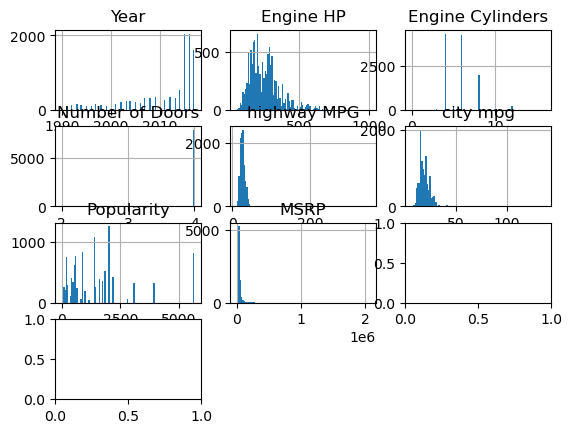

In [64]:
# TODO
import matplotlib.pyplot as plt

plt.figure(figsize=(400, 100))
df.hist(bins=100);

In [65]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG',
       'city mpg', 'Popularity', 'MSRP', 'Engine HP per Cylinder',
       'Engine HP per Year'],
      dtype='object')

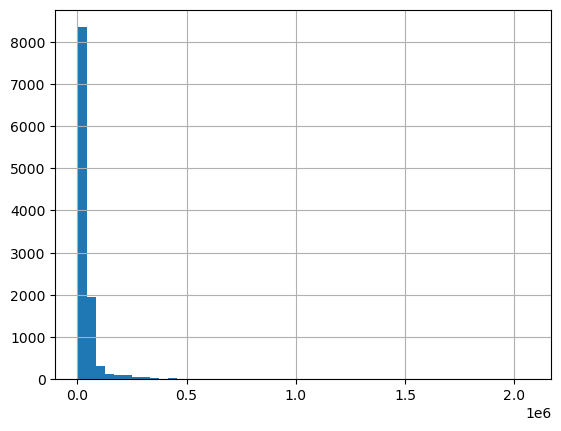

In [66]:
df['MSRP'].hist(bins=50);

In [161]:
corr_matrix = df.drop(columns=['Make','Model','Engine Fuel Type','Transmission Type','Driven_Wheels','Vehicle Size','Vehicle Style']).corr()
corr_matrix

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
Year,1.000000,0.337207,-0.026926,0.245804,0.265521,0.220037,0.086693,0.209315,0.586169,0.331606
Engine HP,0.337207,1.000000,0.788325,-0.128704,-0.423809,-0.474851,0.041352,0.658987,0.669585,0.999979
Engine Cylinders,-0.026926,0.788325,1.000000,-0.147885,-0.614795,-0.634509,0.042393,0.552042,0.110687,0.790496
Number of Doors,0.245804,-0.128704,-0.147885,1.000000,0.116846,0.137381,-0.059199,-0.145690,-0.002590,-0.130432
highway MPG,0.265521,-0.423809,-0.614795,0.116846,1.000000,0.842834,-0.024804,-0.207796,-0.030718,-0.426546
city mpg,0.220037,-0.474851,-0.634509,0.137381,0.842834,1.000000,-0.007093,-0.232722,-0.126704,-0.477359
Popularity,0.086693,0.041352,0.042393,-0.059199,-0.024804,-0.007093,1.000000,-0.048438,0.029064,0.040806
MSRP,0.209315,0.658987,0.552042,-0.145690,-0.207796,-0.232722,-0.048438,1.000000,0.352944,0.659337
Engine HP per Cylinder,0.586169,0.669585,0.110687,-0.002590,-0.030718,-0.126704,0.029064,0.352944,1.000000,0.667173
Engine HP per Year,0.331606,0.999979,0.790496,-0.130432,-0.426546,-0.477359,0.040806,0.659337,0.667173,1.000000


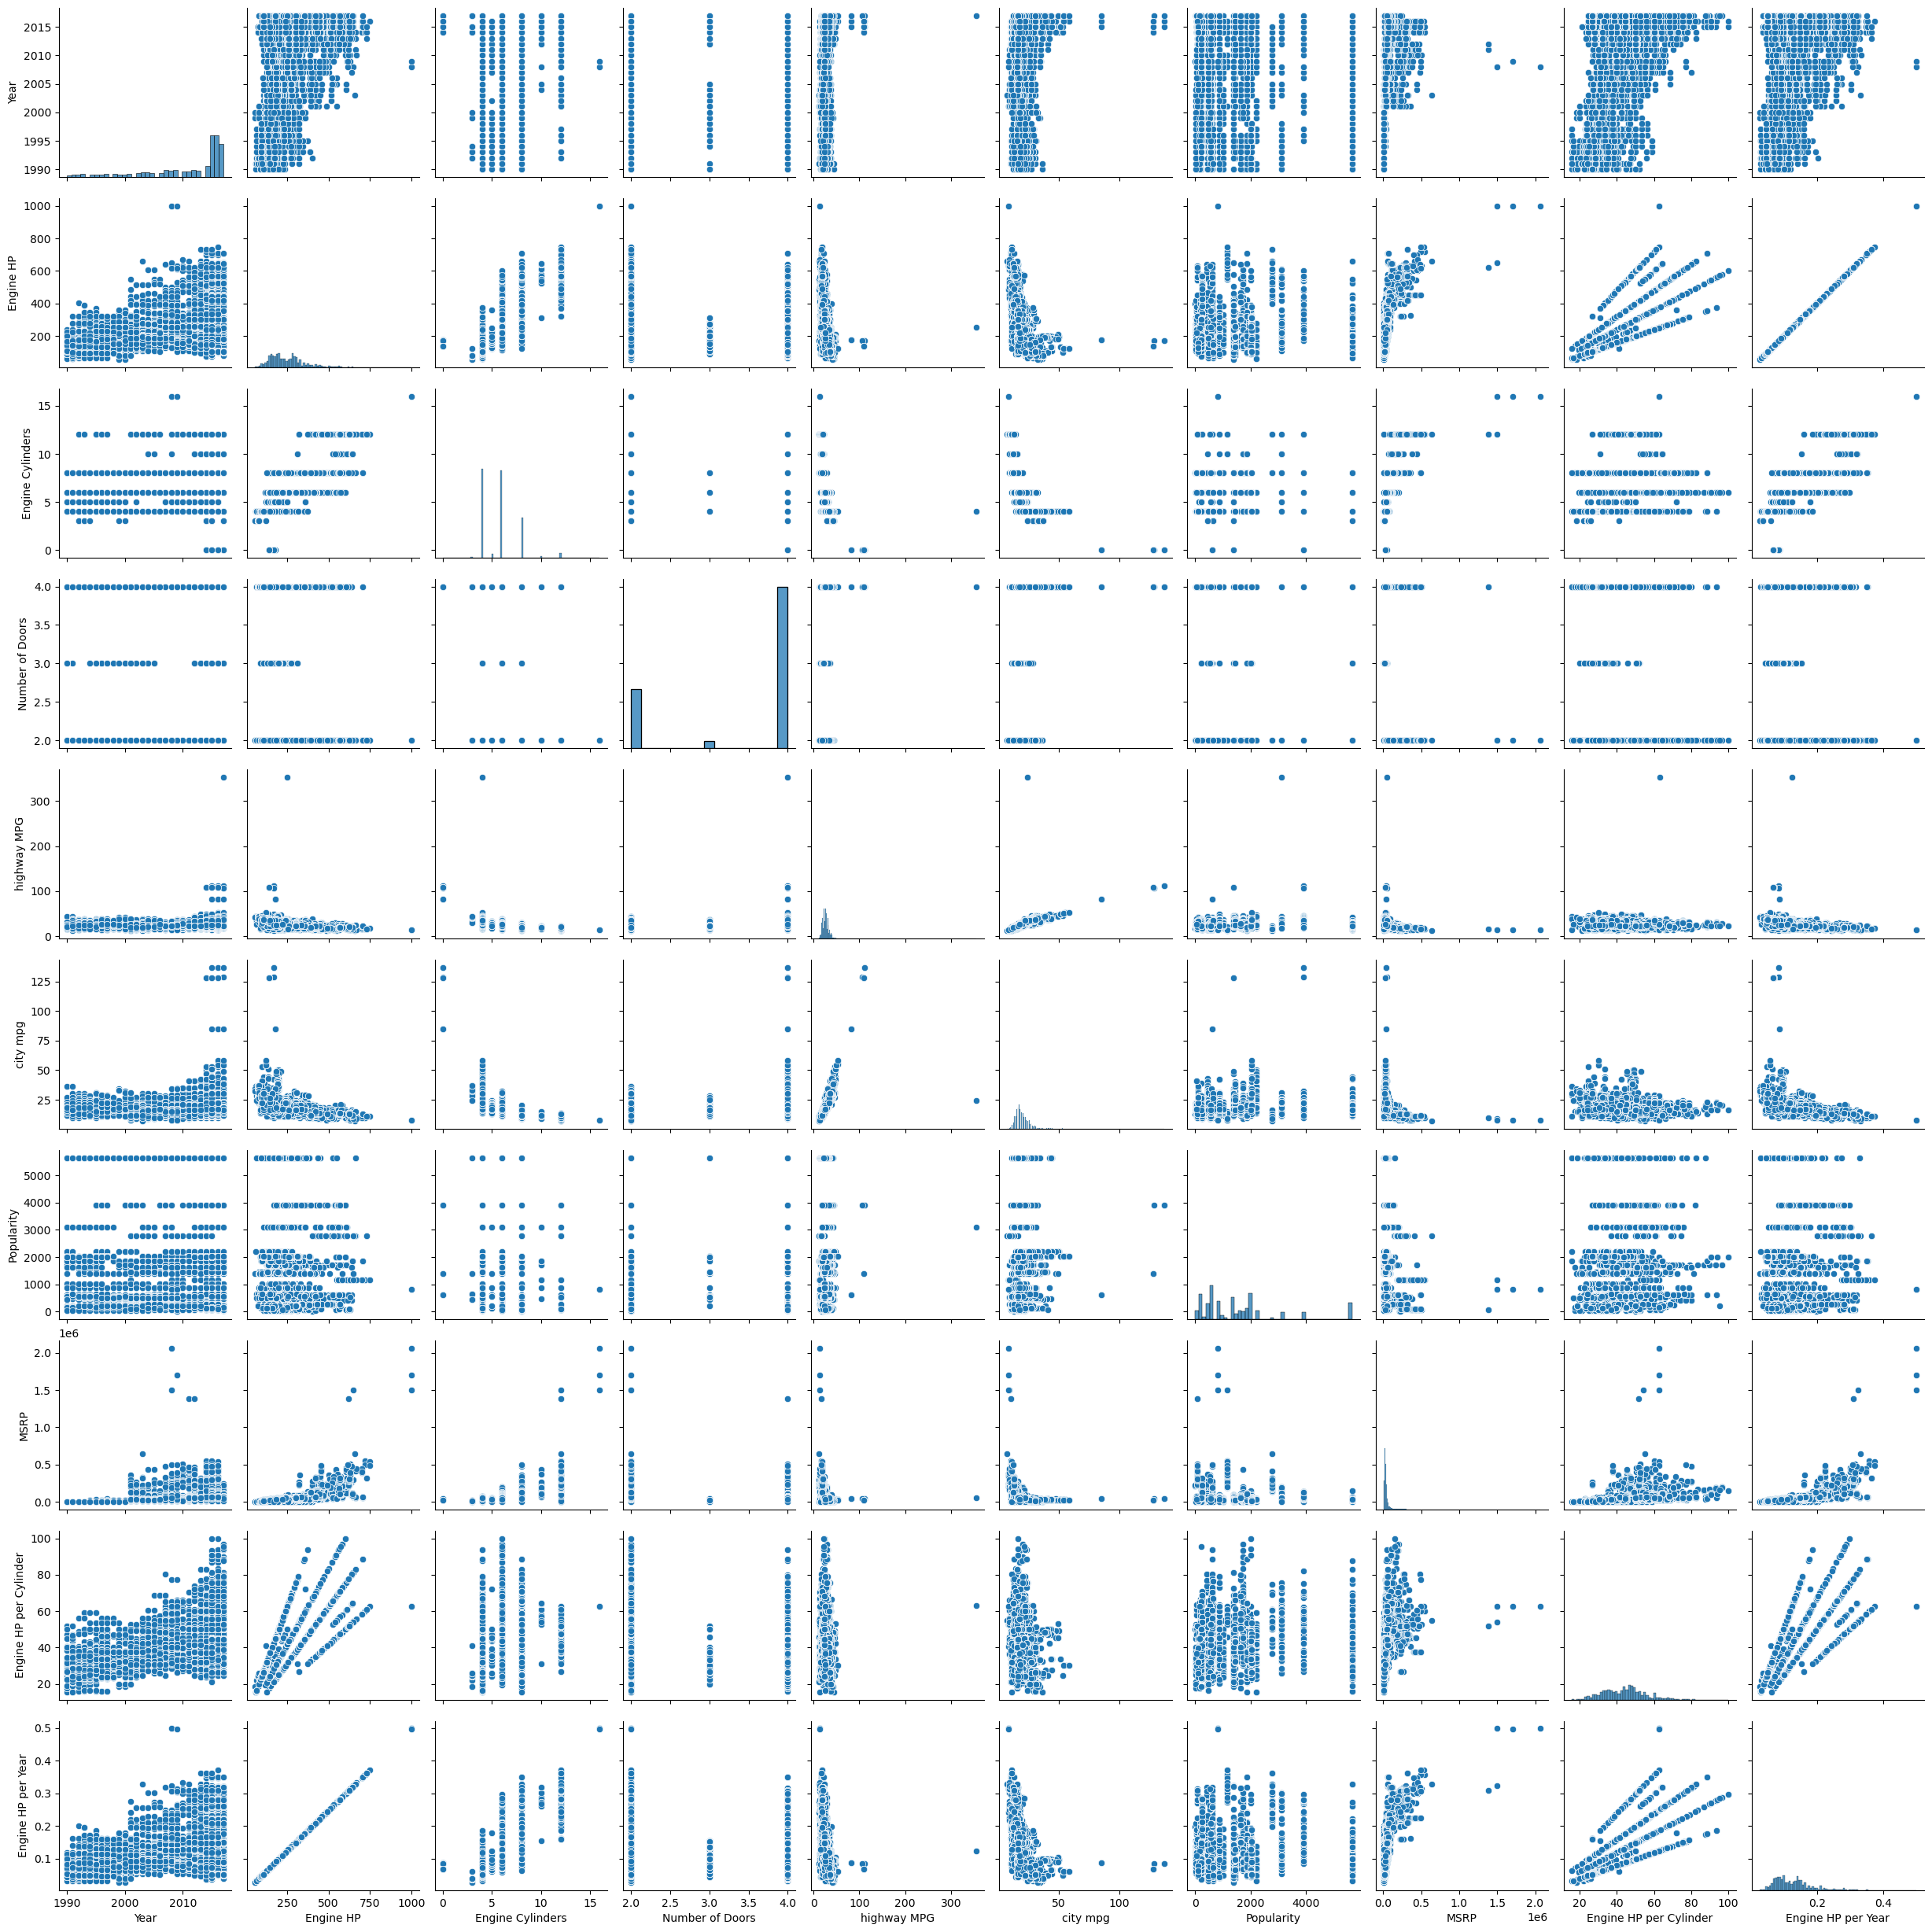

In [68]:
import seaborn as sns

sns.pairplot(df)

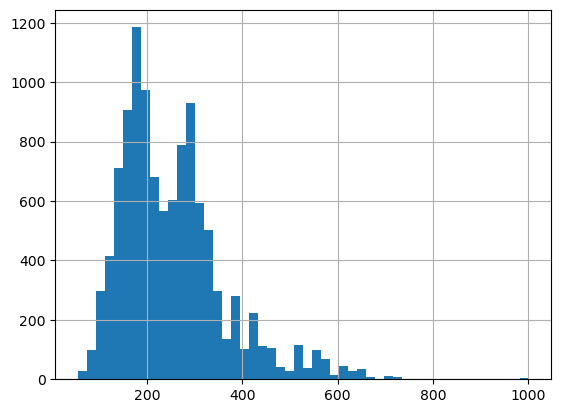

In [69]:
df['Engine HP'].hist(bins=50);

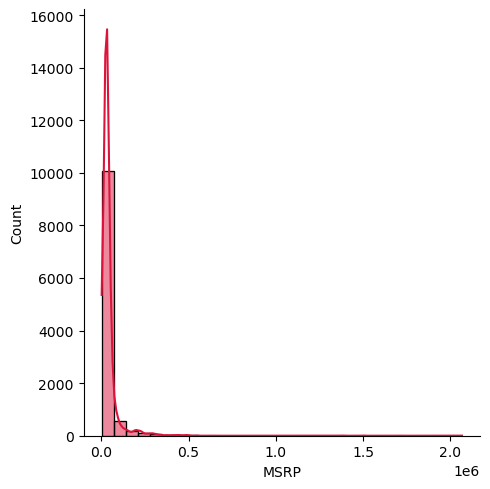

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data=df, x="MSRP", kde=True, bins=30, color="crimson")



In [71]:
df.head(1)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584


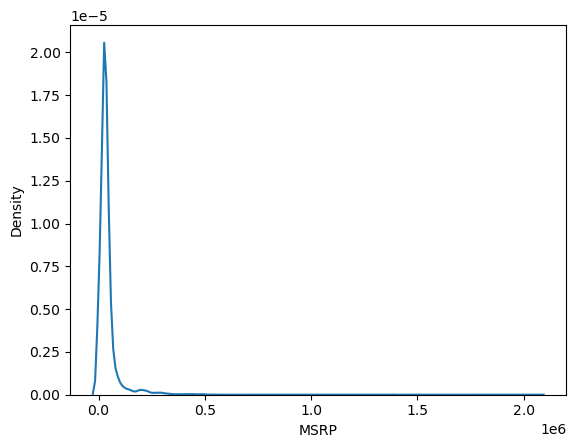

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(data=df, x="MSRP")
plt.show()


## Outlier Detection


- Identify outliers using boxplots
- Decide whether to remove them and explain why?

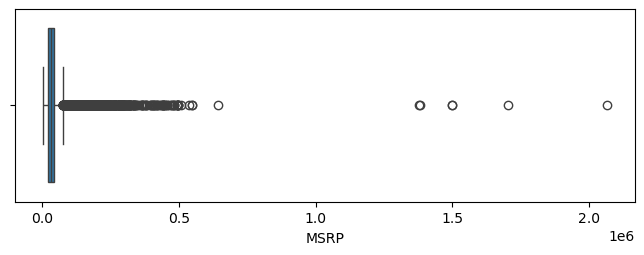

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['MSRP'])
plt.xlabel('MSRP')
plt.show()

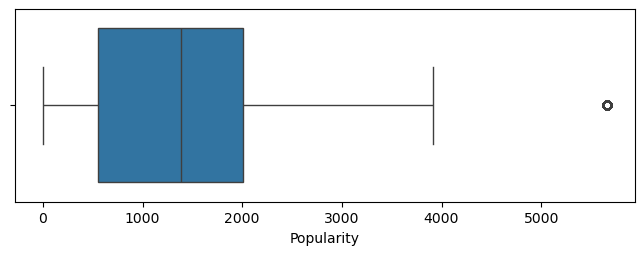

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['Popularity'])
plt.xlabel('Popularity')
plt.show()

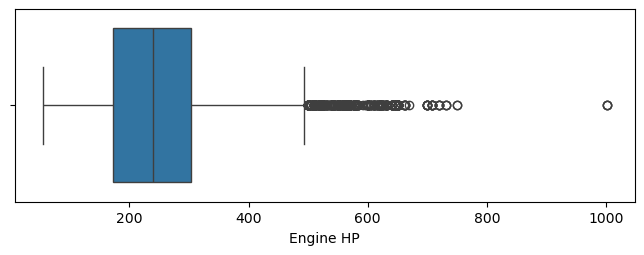

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['Engine HP'])
plt.xlabel('Engine HP')
plt.show()

### Categorical Features



- Countplots
- Number of unique values

In [101]:
df.Make.nunique()

47

In [102]:
df["Transmission Type"].nunique()

5

In [103]:
# TODO
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650,50.000000,0.149180


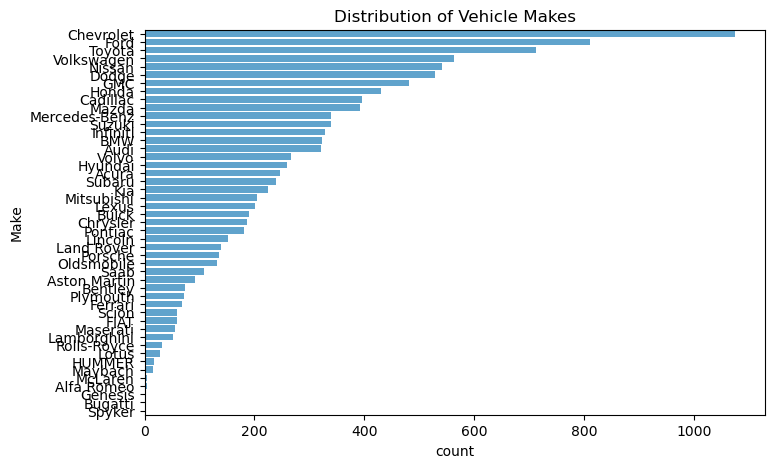

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Make", color="#4EA8DE", order=df["Make"].value_counts().index)
plt.title("Distribution of Vehicle Makes")
plt.show()


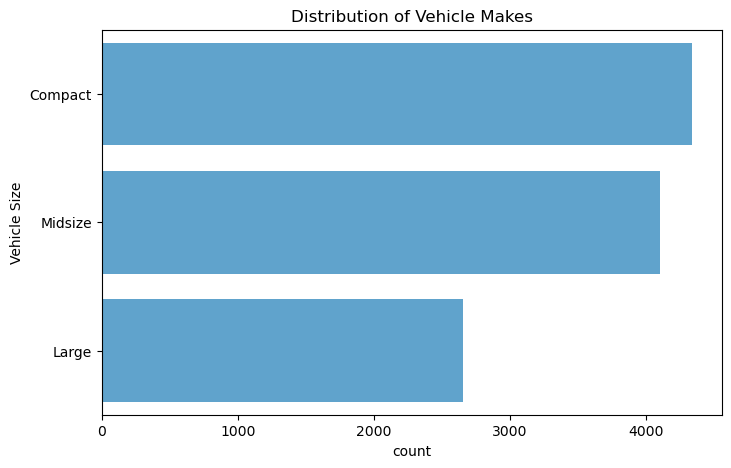

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Vehicle Size", color="#4EA8DE", order=df["Vehicle Size"].value_counts().index)
plt.title("Distribution of Vehicle Makes")
plt.show()


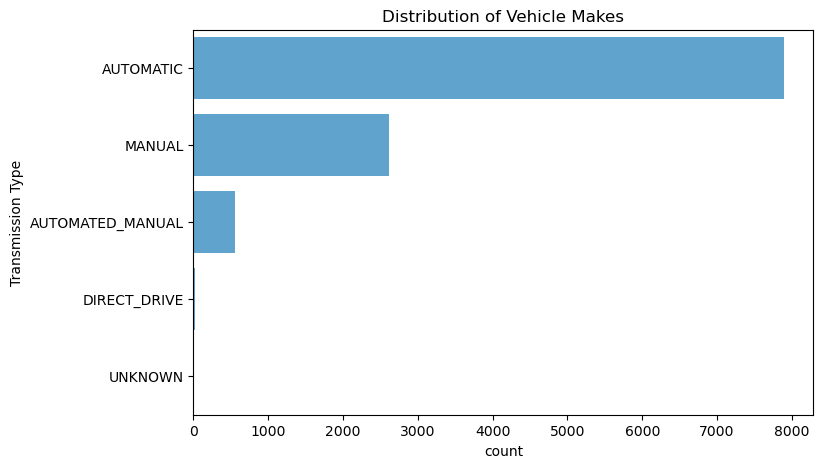

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="Transmission Type", color="#4EA8DE", order=df["Transmission Type"].value_counts().index)
plt.title("Distribution of Vehicle Makes")
plt.show()


In [82]:
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650,50.000000,0.149180


### Relationship with Target

Tasks

- Scatterplots
- Correlation heatmap
- Pairplots (selected columns)


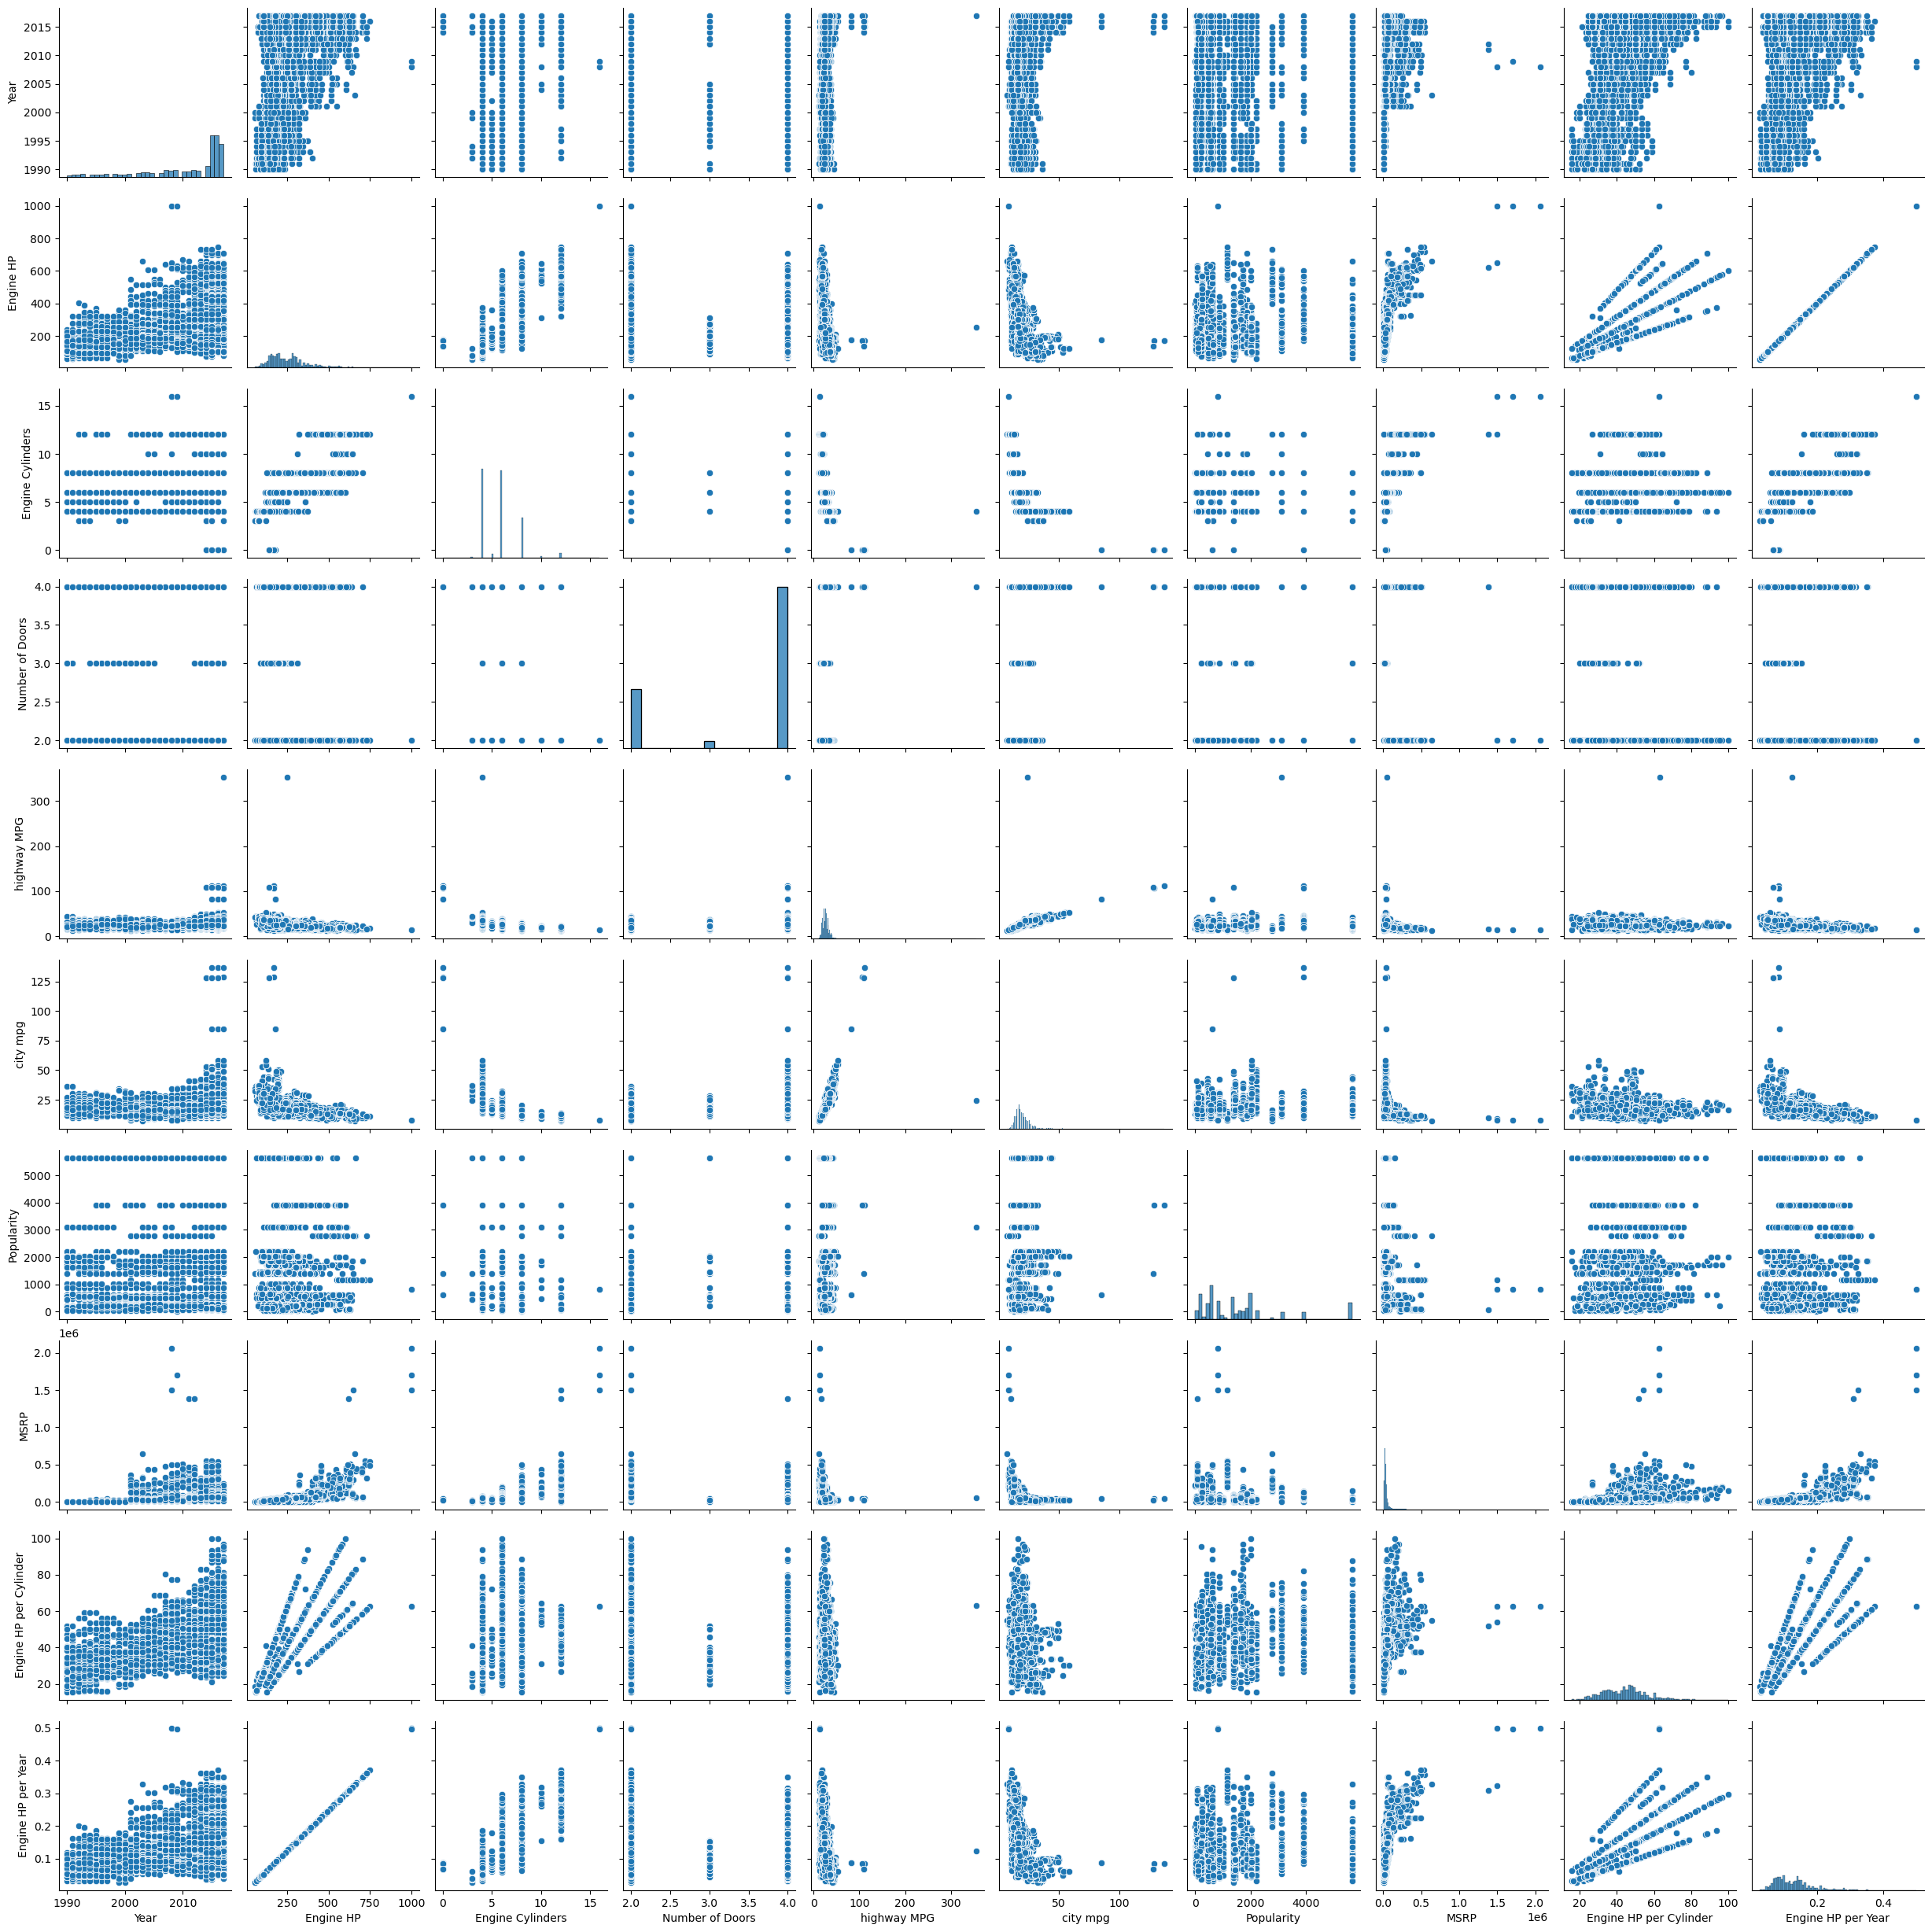

In [83]:
# TODO
import seaborn as sns

sns.pairplot(df)

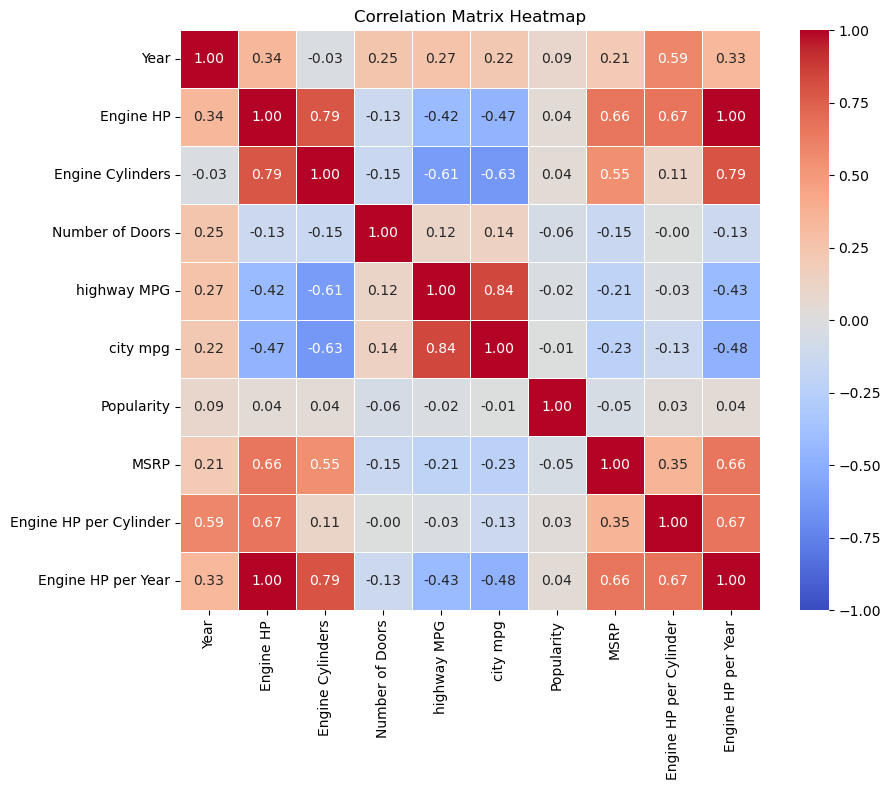

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5,square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()


Questions:

- Which features seem most correlated with price?

In [43]:
# TODO - No Code
#Engine HP and Engine Cylinders

## Feature Engineering
Create at least two new features that may improve performance.

Possible ideas

- Engine HP per Cylinder

- Power-to-weight proxy


**You should do the same step for the `val` and `test`**

In [46]:
# TODO
# I already made this in the beginning
df['Engine HP per Cylinder'] = df['Engine HP'] / df['Engine Cylinders'].replace(0, np.nan)
df['Engine HP per Year'] = df['Engine HP'] / df['Year']
df.head(1)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650,50.000000,0.149180
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350,50.000000,0.149180
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450,38.333333,0.114371
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500,38.333333,0.114371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,46120,50.000000,0.149105
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,56670,50.000000,0.149105
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,50620,50.000000,0.149105
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,Midsize,4dr Hatchback,23,16,204,50920,50.000000,0.149031


## Preprocessing
Identify numerical and categorical columns and build a ColumnTransformer.

In [121]:
df.head(1)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135,55.833333,0.166584


In [139]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP,Engine HP per Cylinder,Engine HP per Year
count,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,11092.000000,1.109200e+04,11092.000,11092.000000
mean,2010.693833,253.528579,5.687973,3.450415,26.272899,19.300667,1556.681302,4.190853e+04,inf,0.126025
std,7.241249,110.184621,1.766331,0.874700,7.481404,6.605683,1443.586149,6.174305e+04,NaN,0.054628
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03,15.500,0.027500
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.153750e+04,35.000,0.085700
50%,2015.000000,240.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.059750e+04,44.375,0.118989
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.302250e+04,50.500,0.150794
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06,inf,0.498506


In [163]:
df['Engine HP per Cylinder'].isnull().sum()

np.int64(13)

In [178]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

num_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'), MinMaxScaler()) # seq of steps
cat_pipe_onehot = make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore', sparse_output=False))
cat_pipe_ordinal=make_pipeline(SimpleImputer(strategy='most_frequent'), OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))


In [179]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG',
       'city mpg', 'Popularity', 'MSRP', 'Engine HP per Cylinder',
       'Engine HP per Year'],
      dtype='object')

In [180]:
# TODO
from sklearn.compose import ColumnTransformer

num_cols = ['Year', 'Engine HP','Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg','Popularity','Engine HP per Cylinder','Engine HP per Year']
cat_cols_onehot = ['Engine Fuel Type','Transmission Type','Driven_Wheels','Vehicle Style']
cat_cols_ordinal= ['Make','Model','Vehicle Size']

preprocess_pipe = ColumnTransformer(
                                    [("cat_preprocess_onehot", cat_pipe_onehot, cat_cols_onehot),
                                     ("cat_preprocess_ordinal", cat_pipe_ordinal, cat_cols_ordinal),
                                     ("num_preprocess", num_pipe,     num_cols)]
                                     )
preprocess_pipe

,transformers,"[('cat_preprocess_onehot', ...), ('cat_preprocess_ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [181]:
df['Model'].nunique()

904

## Pipeline
Create a preprocessing + model pipeline.

In [182]:
# TODO 
X_train.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG',
       'city mpg', 'Popularity', 'Engine HP per Cylinder',
       'Engine HP per Year'],
      dtype='object')

In [183]:
X_train.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,Engine HP per Cylinder,Engine HP per Year
count,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7098.000000,7089.000000,7098.000000
mean,2010.753311,253.210200,5.686531,3.461820,26.356579,19.345027,1552.152719,44.102196,0.125862
std,7.287751,110.689756,1.775776,0.868901,7.911538,6.769250,1437.502614,11.598024,0.054876
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,15.500000,0.027500
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,35.000000,0.085657
50%,2015.000000,240.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,44.375000,0.118989
75%,2016.000000,302.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,50.333333,0.150223
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,96.666667,0.498506


In [184]:
X_train.isnull().sum()

Make                      0
Model                     0
Year                      0
Engine Fuel Type          0
Engine HP                 0
Engine Cylinders          0
Transmission Type         0
Driven_Wheels             0
Number of Doors           0
Vehicle Size              0
Vehicle Style             0
highway MPG               0
city mpg                  0
Popularity                0
Engine HP per Cylinder    9
Engine HP per Year        0
dtype: int64

## Baseline Model
Train a Linear Regression model and evaluate using MAE, RMSE and MSE.

In [185]:
# TODO
from sklearn.linear_model import LinearRegression

full_pipe = make_pipeline(preprocess_pipe, LinearRegression())
full_pipe.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_preprocess_onehot', ...), ('cat_preprocess_ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


How well does Linear Regression perform?

In [186]:
# TODO 
from sklearn.metrics import mean_absolute_error

y_pred = full_pipe.predict(X_train)

mean_absolute_error(y_train, y_pred)


19400.30640453992

In [187]:
y_pred = full_pipe.predict(X_val)

mean_absolute_error(y_val, y_pred) 

18487.049626835666

## Model Comparison
Compare at least two regression models.

In [189]:
# TODO
from sklearn.tree import DecisionTreeRegressor

full_pipe = make_pipeline(preprocess_pipe, DecisionTreeRegressor())
full_pipe.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_preprocess_onehot', ...), ('cat_preprocess_ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [190]:
y_pred = full_pipe.predict(X_train) # merorize (overfitting) VS learn 

mean_absolute_error(y_train, y_pred)

1269.9899549168779

In [191]:
y_pred = full_pipe.predict(X_val)

mean_absolute_error(y_val, y_pred) 

3543.2249483568075

## Hyperparameter Tuning
Tune your best model using GridSearchCV.

In [238]:
# TODO
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

grid = {'decisiontreeregressor__max_depth': [5, 6, 7, 8, 9, 10],
        'decisiontreeregressor__max_leaf_nodes': [10, 20, 30, 40, 60] 
        #'stepName__paramter':[]
       }

model = GridSearchCV(full_pipe, grid)

model.fit(X_train, y_train)
print("MAE:", mean_absolute_error(y_val, y_pred))


MAE: 6800.126076964736


Repeat using RandomizedSearchCV.

In [250]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

pipe = Pipeline([
    ("prep", preprocess_pipe),
    ("tree", DecisionTreeRegressor())
])

grid = {
    "tree__max_depth": [5, 6, 7, 8, 9, 10],
    "tree__max_leaf_nodes": [10, 20, 30, 40, 60]
}

model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=grid,
    n_iter=5,
    cv=5
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))

MAE: 6984.529813935241


Which method was faster? Did both produce similar results?

In [251]:
# TODO
# Randomized Search was faster. MAE in Grid Search was better than Randomized Search.

## Final Test Evaluation
Evaluate **only once** on the held-out test set.

In [245]:
# TODO
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)

7082.500359307392

## Deployment (Bonus)
Deploy your model using streamlit

In [246]:
full_pipe

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_preprocess_onehot', ...), ('cat_preprocess_ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [247]:
import joblib
joblib.dump(full_pipe, "model.pkl")

['model.pkl']

## Reflection
Summarize findings.

- Which preprocessing steps were essential?
- Which model performed best?
- Why?
- Did hyperparameter tuning improve performance?
- Which features contributed most?
- What additional data would improve predictions?
- If this model were deployed in production, what challenges might arise?

In [ ]:
# TODO
# Preprocessing: dropping Market Category (31% missing) and the null rows in core columns, deduping 720 rows, and the OneHot/Ordinal split for encoding (with a note that ordinal-encoding Make/Model, 904 unique models).

# Best model: the untuned Decision Tree (MAE=3,543) beat Linear Regression (MAE=18,487) by a wide margin.

# Tuning: actually made things worse in your notebook — both GridSearchCV (≈6,800) and RandomizedSearchCV (≈6,923) scored worse than the untuned tree. I flagged why: the search grid (max_depth 5-10, max_leaf_nodes 10-60) likely underfits relative to the default, and there's a bug where the GridSearchCV cell prints an MAE using a stale y_pred instead of predicting from the newly tuned model.

# Feature importance: .feature_importances_ was never actually pulled from the tree, so I answered from the correlation matrix instead (Engine HP and Engine Cylinders are strongest) and flagged that "Engine HP per Year" correlates 0.9999 with raw Engine HP — it's redundant, not new signal.

# Additional data: curb weight/dimensions, trim details, region, more samples per rare Make/Model.

# Production risks: the model actually pickled at the end is the untuned tree, not the tuned one you evaluated on the test set — a real mismatch worth fixing before deployment — plus drift and unknown-category handling for Make/Model.